In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ----------------------
# Bird Mating Optimizer 
# ----------------------

def bird_mating_optimizer(obj_fn, dim, bounds, pop_size=50, max_gens=500, seed=None):
    """
    Bird Mating Optimizer (BMO)
    obj_fn: objective function
    dim: dimensionality, number of variables
    bounds: (lower, upper) pair or array of bounds
    pop_size: number of birds 
    max_gens: number of iterations (generations)
    """

    # set seed
    if seed is not None:
        np.random.seed(seed)

    # bounds is always an array of shape (dim, 2)
    bounds = np.array(bounds)
    if bounds.shape == (2,):
        bounds = np.tile(bounds, (dim, 1))

    # bounds is 2 columns: low, high
    low = bounds[:, 0]
    high = bounds[:, 1]

    # initialize population with bounds
    pop = np.random.uniform(low, high, size=(pop_size, dim))
    # fitness values for each bird with the function
    fit = np.array([obj_fn(x) for x in pop])

    # all values clipped to bounds
    def clip(x):
        return np.clip(x, low, high)

    # female and male bird split (top 50% are females)
    def sort_population():
        idx = np.argsort(fit)
        females = idx[:pop_size//2]
        males = idx[pop_size//2:]
        return females, males

    # logistic chaotic values for promiscuous
    chaos = np.random.rand()

    # track convergence
    history = []


    # for generation in max_gens
    for gen in range(max_gens):
        females, males = sort_population()

        # time-varying weight w, decreases from ~2 to ~0
        w = 2.5 - (2.5 - 0.25) * (gen / max_gens)

        new_birds = []
        replace_idx = []

##########################################################################################################################################################################

        # male split
        n_males = len(males)

        # 3 male groups: monogamous, polygamous, promiscuous
        n_mono = n_males // 3
        n_poly = n_males // 3
        n_prom = n_males - n_mono - n_poly    

        mono = males[:n_mono] # monogamous
        poly = males[n_mono:n_mono+n_poly] # polygamous
        prom = males[n_mono+n_poly:] # promiscuous

        # 2 female groups: polyandrous, parthenogenetic
        n_fem = len(females)
        n_polyandry = n_fem // 3
        n_partheno  = n_fem // 3

        polyandrous = females[:n_polyandry] # polyandrous
        partheno    = females[n_polyandry:n_polyandry+n_partheno] # parthenogenetic


#########################################

        # female fitness for selection probabilities, lower = better
        female_fits = fit[females]
        # turn fitness into weights (lower fitness = higher weight)
        maxf = female_fits.max()
        female_weights = (maxf - female_fits) + 1e-10   # avoid zero division
        # normalize to probabilities
        female_prob = female_weights / female_weights.sum()

        # male fitness function for selection probabilities, for polyandry
        male_fits = fit[males]
        # fitness function --> wieghts
        maxm = male_fits.max()
        male_weights = (maxm - male_fits) + 1e-10 # avoid zero division
        male_prob = male_weights / male_weights.sum() 

#########################################


        # -------------------------------------------------------
        # Monogamous males: mate with 1 female, one new solution
        # Male picks 1 interesting female
        # -------------------------------------------------------

        for m in mono:

            # picks female based on fitness probabilities
            f = np.random.choice(females, p=female_prob)

            # male's current position
            x = pop[m]
            # female's current position
            xi = pop[f] 
            # random vector btwn 0 and 1, for diversity
            r = np.random.rand(dim) 

            # monogamy equation
            xb = x + w * r * (xi - x) 
           
            # pick random coordinate
            c = np.random.randint(0, dim)  

            # random value for mutation control
            r1 = np.random.rand() 

            # mutation control threshold
            mcf = 0.9  

            if r1 > mcf:  # if random val > mutation control threshold
                r2 = np.random.rand()
                # equation from paper:
                # # xb(c) = l(c) - r2 * (l(c) - u(c))
                xb[c] = low[c] - r2 * (low[c] - high[c])


            # keep new bird inside the bounds
            xb = clip(xb) 
            # add new bird to the list
            new_birds.append(xb) 
            # which male the new bird will replace
            replace_idx.append(m) 

        
##########################################################################################################################################################################


        # --------------------------------------------------------
        # Polygynous: male mates with 3 females, one new solution
        # Move male towards 3 females
        # --------------------------------------------------------
        

        for m in poly:

            # selecting 3 interesting females
            chosen = np.random.choice(females, size=3, replace=False, p=female_prob)

            x = pop[m].copy()
            # holds dimension influences
            sum_term = np.zeros(dim)

            # for 3 chosen females
            for f in chosen:
                # random vector for diversity for each female
                r = np.random.rand(dim)
                # sum influence of female, x female - x male
                sum_term += r * (pop[f] - x)

            # polygyny equation
            xb = x + w * sum_term

            # random coordinate & value
            c = np.random.randint(0, dim)   
            r1 = np.random.rand()

            # mutation control threshold
            mcf = 0.9

            # if random val 1 > mutation control threshold
            if r1 > mcf:
                # random value
                r2 = np.random.rand()
                # mutation formula
                xb[c] = low[c] - r2 * (low[c] - high[c])

            # clip to bounds
            xb = clip(xb)
            # new bird to list
            new_birds.append(xb)
            # which bird the male bird will replace
            replace_idx.append(m)




##########################################################################################################################################################################




        # --------------------------------------------------------
        # Polyandrous: female mates with 3 males 
        # Move female towards 3 males
        # --------------------------------------------------------


        for f in polyandrous:

            # select 3 interesting males, based on fitness probabilities
            chosen = np.random.choice(males, size=3, replace=False, p=male_prob)

            # female population
            x = pop[f].copy()
            # holds dimension influences
            sum_term = np.zeros(dim)

            # influence from males
            for m in chosen:
                # random vector for diversity
                r = np.random.rand(dim)
                # males influence female
                sum_term += r * (pop[m] - x)  

            # polyandry equation
            xb = x + w * sum_term

            # mutation control factor
            c = np.random.randint(0, dim)
            r1 = np.random.rand()

            mcf = 0.9

            if r1 > mcf:
                r2 = np.random.rand()
                xb[c] = low[c] - r2 * (low[c] - high[c])

            xb = clip(xb)

            new_birds.append(xb)
            replace_idx.append(f)



##########################################################################################################################################################################

    
##########################################################################################################################################################################


        # -----------------------------------------------------
        # Parthenogenesis: small mutation for the best females
        # Female mutates herself to create new solution
        # -----------------------------------------------------


        for f in partheno:

            # current position of female 
            x = pop[f].copy()

            # mutation control factor, time-varying
                # At generation 0 → 0 / max = 0
                # At generation half → 0.5
                # At final generation → 1
            mcfp = 0.1 + 0.8 * (gen / max_gens)
            # mutation factor
            mu = 0.001

            xb = x.copy()
            for i in range(dim):
                r1, r2, r3 = np.random.rand(), np.random.rand(), np.random.rand()
                if r1 > mcfp:
                    # parthenogenesis equation
                    xb[i] = x[i] + mu * (r2 * r3) * x[i]

            # brood in bounds
            xb = clip(xb)
            new_birds.append(xb)
            replace_idx.append(f)
          


##########################################################################################################################################################################


        # ---------------------------
        # Promiscuous new birds (chaotic map)
        # ---------------------------
        # n_promis = max(1, pop_size // 10)
        for _ in range(n_prom):
            # chaos = some random value (above)
            # done with logistic chaotic map (in paper)
            # the logistic chaotic map : https://plus.maths.org/content/maths-minute-logistic-map
                                        # https://en.wikipedia.org/wiki/Logistic_map
            chaos = 4 * chaos * (1 - chaos)
            vals = low + chaos * (high - low)
            xb = clip(vals)
            # replace random male
            m = np.random.choice(prom)
            new_birds.append(xb)
            replace_idx.append(m)



##########################################################################################################################################################################


        # ---------------------------
        # Replacement
        # ---------------------------
        for idx, baby in zip(replace_idx, new_birds):
            fb = obj_fn(baby)
            if fb < fit[idx]:
                pop[idx] = baby
                fit[idx] = fb

        history.append(fit.min())

    best_idx = np.argmin(fit)
    return pop[best_idx], fit[best_idx], history



In [ ]:
# def f9(x): #multimodal w many
#     return np.sum(x**2 - 10 * np.cos(2 * np.pi * x) + 10)


Best fitness: 0.0
Best solution: [ 3.46871691e-10 -3.44906463e-10  5.02394534e-10 -1.42860722e-10
 -1.69682470e-10  3.88581453e-10 -2.85859923e-11  3.71640547e-10
  9.81071057e-11 -1.31173762e-09]


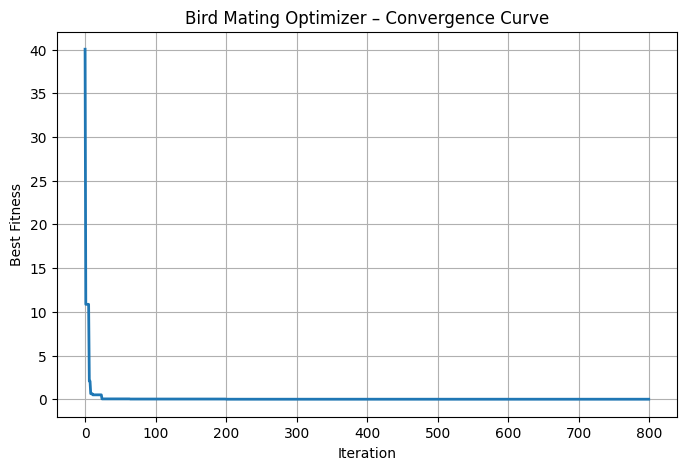

In [ ]:
# best_x, best_f, history = bird_mating_optimizer(
#     f9,
#     dim=10,
#     bounds=[-5.12, 5.12],
#     pop_size=200,
#     max_gens=800,
#     seed=1
# )

# print("Best fitness:", best_f)
# print("Best solution:", best_x)

#     # plot convergence
# plt.figure(figsize=(8, 5))
# plt.plot(history, linewidth=2)
# plt.title("Bird Mating Optimizer – Convergence Curve")
# plt.xlabel("Iteration")
# plt.ylabel("Best Fitness")
# plt.grid(True)
# plt.show()

